In [65]:
import time
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

from network.layer import Layer,WriteConfig

In [66]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=20,adc_last_gap=10)
chip.add_compiler("./code/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 65147
正在编译文件:  ./code/read_point3.txt
正在编译文件:  ./code/read_point3_col.txt
正在编译文件:  ./code/row_read_point3.txt
正在编译文件:  ./code/set_reset.txt
正在编译文件:  ./code/write_verify.txt
正在编译文件:  ./code/汇编测试代码.txt
正在编译文件:  ./code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ./code/读单点测试.txt


In [67]:
dl = DataLoader()
data = dl.load_csv("./data/HNN_W_matrix_origin.csv")
print(data.shape)
print(np.max(data),np.min(data))

(100, 100)
0.16640375538417881 -0.13960279590415514


In [4]:
pos = (30,130,20,120)
v_base = chip.read_chunk_parallel2(*pos,read_voltage=0.1,tg=5,gain=3,
                                    from_row=False,out_type=0,compute=True)
# print(v_base)
print(chip.voltage_to_cond(v_base))

[[27876.75099948]
 [20069.73479415]
 [30409.78728599]
 [20899.45677053]
 [29148.99136326]
 [21237.06778161]
 [29677.34305857]
 [20628.60499893]
 [28519.54710532]
 [20891.82714316]
 [29164.250618  ]
 [20476.01245155]
 [28347.88048952]
 [20865.12344737]
 [27829.06582842]
 [20119.32737205]
 [28147.60277108]
 [20172.73476363]
 [28847.62108219]
 [20868.93826106]
 [30318.23175756]
 [20657.21610157]
 [28834.26923429]
 [20683.91979736]
 [28555.78783532]
 [20430.23468734]
 [27838.60286264]
 [20281.45695364]
 [28435.62120426]
 [20168.91994995]
 [29356.89870907]
 [19882.80892361]
 [27487.64000366]
 [20071.64220099]
 [30037.84295175]
 [21767.32688375]
 [29618.21344646]
 [20750.67903684]
 [29021.19510483]
 [20514.1605884 ]
 [28843.8062685 ]
 [20952.86416211]
 [28574.86190374]
 [20596.17908261]
 [29189.04690695]
 [20994.82711264]
 [28658.7878048 ]
 [20413.06802576]
 [28870.50996429]
 [20191.80883206]
 [30140.84292123]
 [20865.12344737]
 [28807.5655385 ]
 [21151.23447371]
 [28624.45448164]
 [21109.27

In [9]:
ans0=[]
ans1=[]
# for i in range(10):
#     pos = (50,51,20+i*10,30+i*10)
for i in range(100):
    pos = (50,51,20,21+i)
    need_read = np.zeros((256,256))
    need_read[pos[0]:pos[1],pos[2]:pos[3]] = 1
    # if i<20:
    #     voltage_base=chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=False,out_type=0)
    #     voltage=chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=False,out_type=0)
    # else:
    voltage_base=chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=3,from_row=False,out_type=0)
    voltage=chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=3,from_row=False,out_type=0)

    # print(type(voltage),type(voltage_base))
    cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[pos[0]:pos[1],0]
    # print(cond)
    ans0.append(cond[0])

    voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=False,out_type=0)
    voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=False,out_type=0)
    cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
    # W = cond/500*0.17
    # plot_cond(cond,vmin=-500,vmax=500)
    # plot_cond(W,vmin=-0.5,vmax=0.5)
    # W=W.clip(-0.1,0.1)
    # plot_cond(W,vmin=-0.1,vmax=0.1)

    # print(np.sum(cond,axis=1))
    ans1.append(np.sum(cond,axis=1)[0])

print(ans0)
print(ans1)


[698.1109042634357, 1462.9810480056153, 2237.3882259590437, 2958.388012329478, 3677.4803918576627, 4364.146855067597, 5027.924436170539, 5682.164983062228, 6303.97961363567, 6893.368327890866, 7414.090395825068, 7995.8494827112645, 9729.682302316354, 10227.515488143557, 10771.126438184758, 10633.793145542772, 11621.829889828181, 12028.107547227395, 12443.922238837853, 12886.440626239813, 13885.921811578724, 14280.755027924437, 14627.903073213905, 14997.940000610371, 16060.365611743524, 16361.735892818995, 16636.402478102973, 16928.23572496719, 17801.828058717612, 18087.939085055088, 19190.420239875482, 19421.216467787715, 20243.308816797387, 20453.12356944487, 20645.7716605121, 20868.93826105533, 21124.530777916807, 21282.84554582354, 21551.789910580766, 21607.104709006013, 21723.456526383252, 21912.289803765987, 22095.40086062197, 22261.3452558977, 22312.845240638446, 22614.215521713922, 22762.993255409405, 22267.06747642445, 22465.437788018433, 22633.28959013642, 22808.7710196234, 22

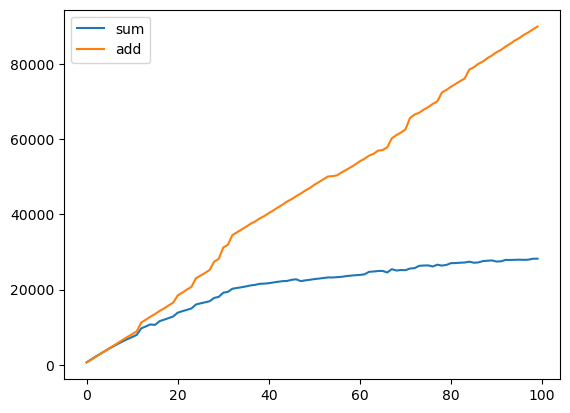

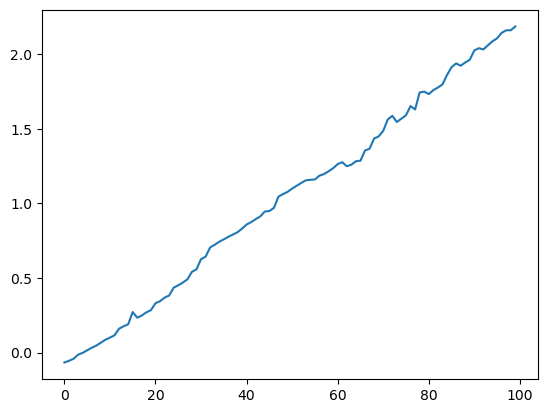

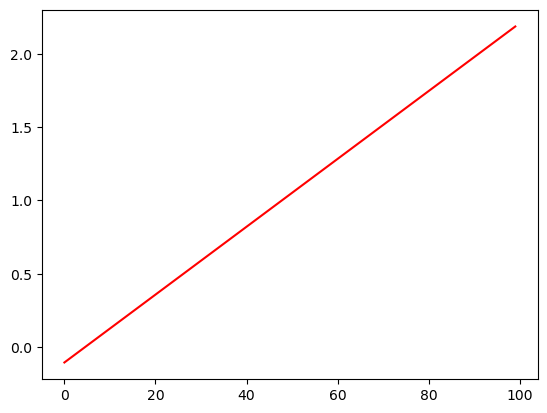

0.023164526351113705 -0.105965044366316


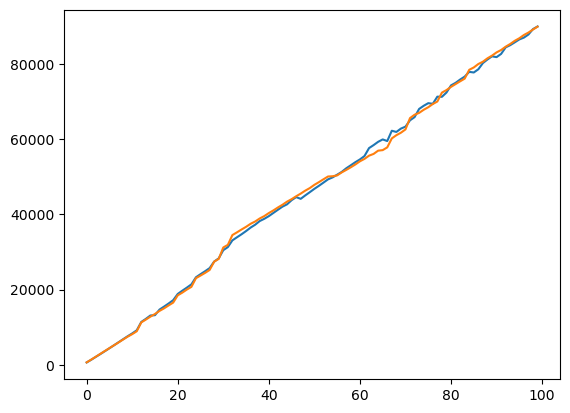

In [53]:
plt.plot(ans0,label="sum")
plt.plot(ans1,label="add")

plt.legend()
plt.show()

plt.plot(np.array(ans1)/np.array(ans0)-1)
plt.show()

slope,intercept = np.polyfit(list(range(100)), np.array(ans1)/np.array(ans0)-1, 1)  # 返回斜率和截距
ans_tmp = [i*slope+intercept for i in range(100)]
plt.plot(list(range(100)), ans_tmp, color='red', label=f'cond = {slope:.2f} * tg + {intercept:.2f}')  # 拟合直线
plt.show()
print(slope,intercept)

ans_tmp = np.array(ans_tmp)+1
ans_tmp = ans_tmp*np.array(ans0)
# t = [v * ((i+1)*slope+intercept) for i,v in enumerate(ans0)]
plt.plot(ans_tmp)  # 拟合直线
plt.plot(ans1,label="add")

In [128]:
pos = (30,130,20,120)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)

print(np.sum(cond>1400,axis=1))

[ 5  4 13  2  5  9  7  4  4  7  6  4  2  7  3  3  4  3  3  5 10  5  4  4
  4  5  4  2  5  4  7  2  2  8  6  8  6  3  2  1  3  9  1  4  6  7  5  3
  6  3  7  2  5  4  4  6 19 20  2  5  3  8  7  7  2  2  2  2  2  2  3  3
  3  6  3  5  7  6  0 11  2  4  4  8  4  4  5  3  5  7  4  4  2  5 23  6
  3  6  4  3]


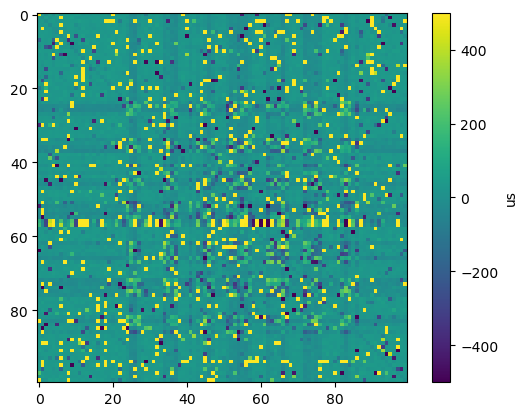

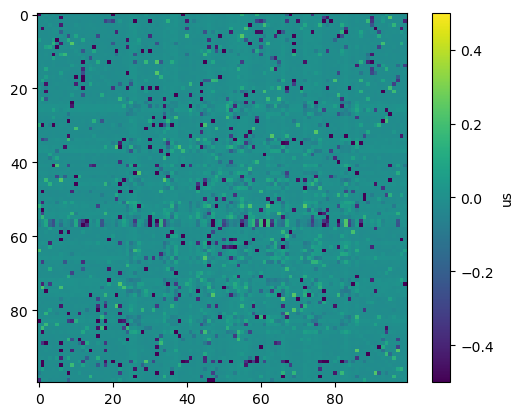

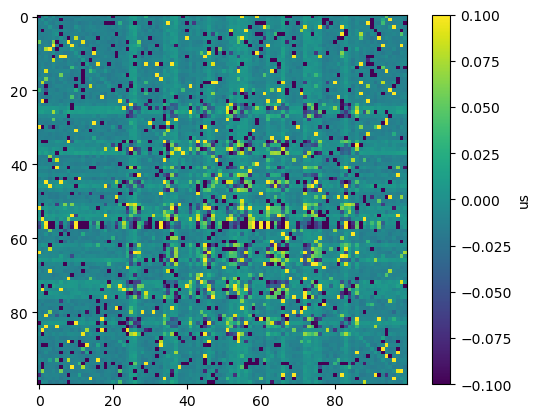

In [ ]:
pos = (30,130,20,120)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)-700


W = -cond/500*0.17
plot_cond(cond,vmin=-500,vmax=500)
plot_cond(W,vmin=-0.5,vmax=0.5)
W=W.clip(-0.1,1)
plot_cond(W,vmin=-0.1,vmax=0.1)
# print(np.sum(cond,axis=1))

In [199]:
pos = (30,130,20,120)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
print(np.max(cond, axis=1))

print(cond.shape)
hnn_refercen = np.ones((100,100))*700

cond[cond>1200]=1000
# cond[cond<200]=200
W = (cond-700)/500*0.17

[2811.35196168 2100.51908028 2856.94658748 2200.25732421 2255.35083039
 2378.20301657 2155.9292158  2288.91354105 2528.91858519 2197.4076601
 3084.60308713 2091.65345859 1896.29315221 2350.97289283 1912.1246195
 1946.32058885 2194.87462533 2663.80268652 2433.92978144 2127.74920402
 2991.8306888  2797.73689981 3116.89928041 2128.69909205 2375.66998181
 2164.79483748 2089.43705317 2461.47653453 2254.08431301 2407.64954574
 3095.36848489 2826.23354093 2908.87380019 3032.04261572 2498.52216799
 2371.87042966 2519.73633416 2062.84018812 2369.65402424 1787.37265724
 2724.27889157 2197.72428945 2701.48157867 2689.13303418 2149.91325823
 2198.35754814 2784.75509663 2932.93763048 2457.04372369 2288.5969117
 2279.09803133 2147.6968528  2427.28056518 2324.69265713 2142.94741262
 2139.46448981 3822.98272162 3883.77555602 1953.60306381 2178.7265287
 3035.84216787 2234.13666422 2238.88610441 2837.31556804 2775.25621625
 1822.51851463 1775.65737145 1789.27243332 2113.50088345 2110.96784869
 2236.9863

In [200]:
def forward(state_flat:np.ndarray):
    """
        state_flat:为1*100的np数组
        split_type = 0,就是采用
        0.023164526351113705 -0.105965044366316
    """
    state_flat_new = state_flat.reshape(1,100)
    pos = (30,130,20,120)
    # 先处理正输入
    col_index = np.where(state_flat_new > 0)[1]+pos[2]
    col_index = col_index.tolist()
    # print(col_index)
    if col_index:
        v_base = chip.read_chunk_parallel2(*pos,row_index=None,col_index=[col_index],read_voltage=0,tg=5,gain=3,
                                            from_row=False,out_type=0,compute=True)
        v_pos = chip.read_chunk_parallel2(*pos,row_index=None,col_index=[col_index],read_voltage=0.1,tg=5,gain=3,
                                                    from_row=False,out_type=0,compute=True)
        # 返回的是100*1的np数组
        v_cond_pos = chip.voltage_to_cond(v_pos-v_base)*(len(col_index)*0.023164526351113705-0.105965044366316+1)
        v_cond_pos-=int(len(col_index)*700)


    else:
        v_cond_pos = np.zeros((pos[3]-pos[2],1))
    
    # 再处理负输入
    col_index = np.where(state_flat_new < 0)[1]+pos[2]
    col_index = col_index.tolist()
    # print(col_index)
    if col_index:
        v_base = chip.read_chunk_parallel2(*pos,row_index=None,col_index=[col_index],read_voltage=0,tg=5,gain=3,
                                    from_row=False,out_type=0,compute=True)
        v_neg = chip.read_chunk_parallel2(*pos,row_index=None,col_index=[col_index],read_voltage=0.1,tg=5,gain=3,
                                                    from_row=False,out_type=0,compute=True)
        
        v_cond_neg = chip.voltage_to_cond(v_neg-v_base)*(len(col_index)*0.023164526351113705-0.105965044366316+1)
        v_cond_neg-=int(len(col_index)*700)

    else:
        v_cond_neg = np.zeros_like(v_cond_pos)


    v_cond = v_cond_pos - v_cond_neg
    ans = (v_cond/500*0.17).flatten()
    # print(ans)
    return ans

In [201]:
# def forward(state_flat:np.ndarray):
#     """
#         state_flat:为1*100的np数组
#         split_type = 0,就是采用
#     """
#     state_flat_new = state_flat.reshape(1,100)
#     pos = (30,130,20,120)
#     # 先处理正输入
#     col_index = np.where(state_flat_new > 0)[1]+pos[2]
#     col_index = col_index.tolist()
#     # print(col_index)
#     if col_index:
#         v_base = chip.read_chunk_parallel2(*pos,row_index=None,col_index=[col_index],read_voltage=0,tg=5,gain=3,
#                                             from_row=False,out_type=0,compute=True)
#         v_pos = chip.read_chunk_parallel2(*pos,row_index=None,col_index=[col_index],read_voltage=0.1,tg=5,gain=3,
#                                                     from_row=False,out_type=0,compute=True)
#         # 返回的是100*1的np数组
#         v_cond_pos = chip.voltage_to_cond(v_pos-v_base)
#         print(len(col_index))
#         print(v_cond_pos)
#         v_cond_pos-=int(len(col_index)*500)
#         print(v_cond_pos)


#     else:
#         v_cond_pos = np.zeros((pos[3]-pos[2],1))
    
#     # 再处理负输入
#     col_index = np.where(state_flat_new < 0)[1]+pos[2]
#     col_index = col_index.tolist()
#     # print(col_index)
#     if col_index:
#         v_base = chip.read_chunk_parallel2(*pos,row_index=None,col_index=[col_index],read_voltage=0,tg=5,gain=3,
#                                     from_row=False,out_type=0,compute=True)
#         v_neg = chip.read_chunk_parallel2(*pos,row_index=None,col_index=[col_index],read_voltage=0.1,tg=5,gain=3,
#                                                     from_row=False,out_type=0,compute=True)
#         v_cond_neg = chip.voltage_to_cond(v_neg-v_base)
        
#         v_cond_neg-=int(len(col_index)*700)
#         print(v_cond_neg)

#     else:
#         v_cond_neg = np.zeros_like(v_cond_pos)


#     v_cond = v_cond_pos - v_cond_neg
#     ans = (v_cond/500*0.17).flatten()
#     print(ans)
#     return ans

In [202]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from skimage.transform import resize

(100,)
(100,)
(100,)
(100,)
(100,)


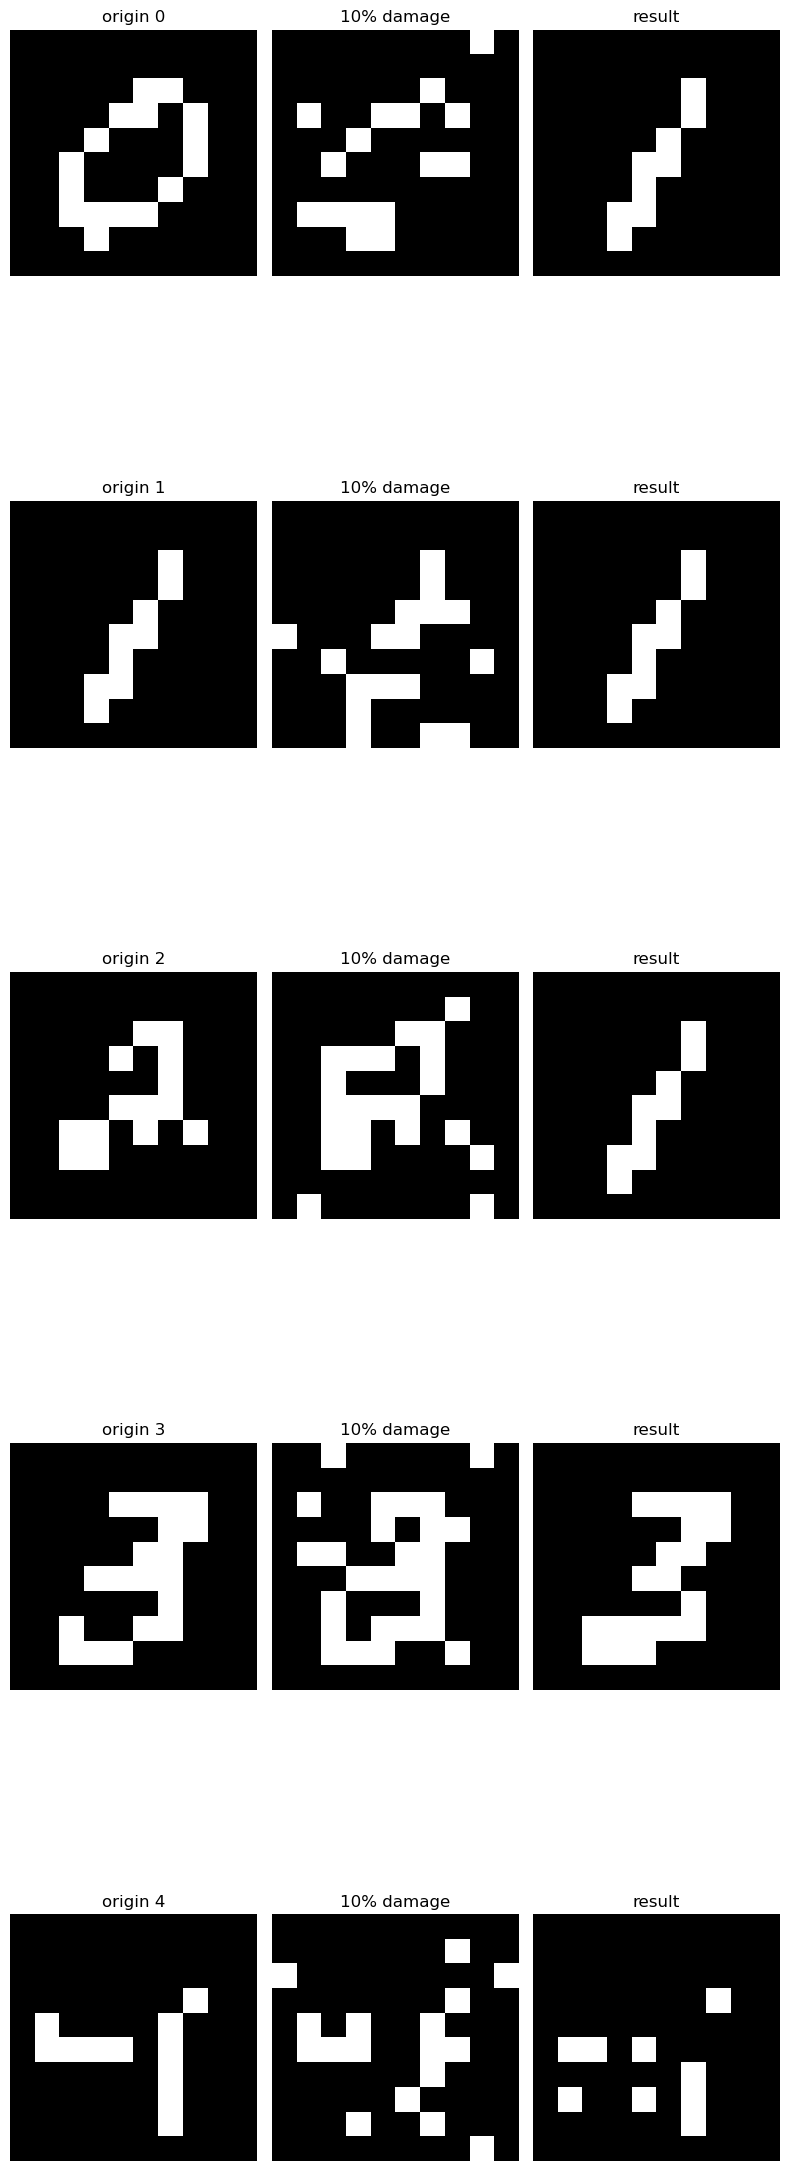

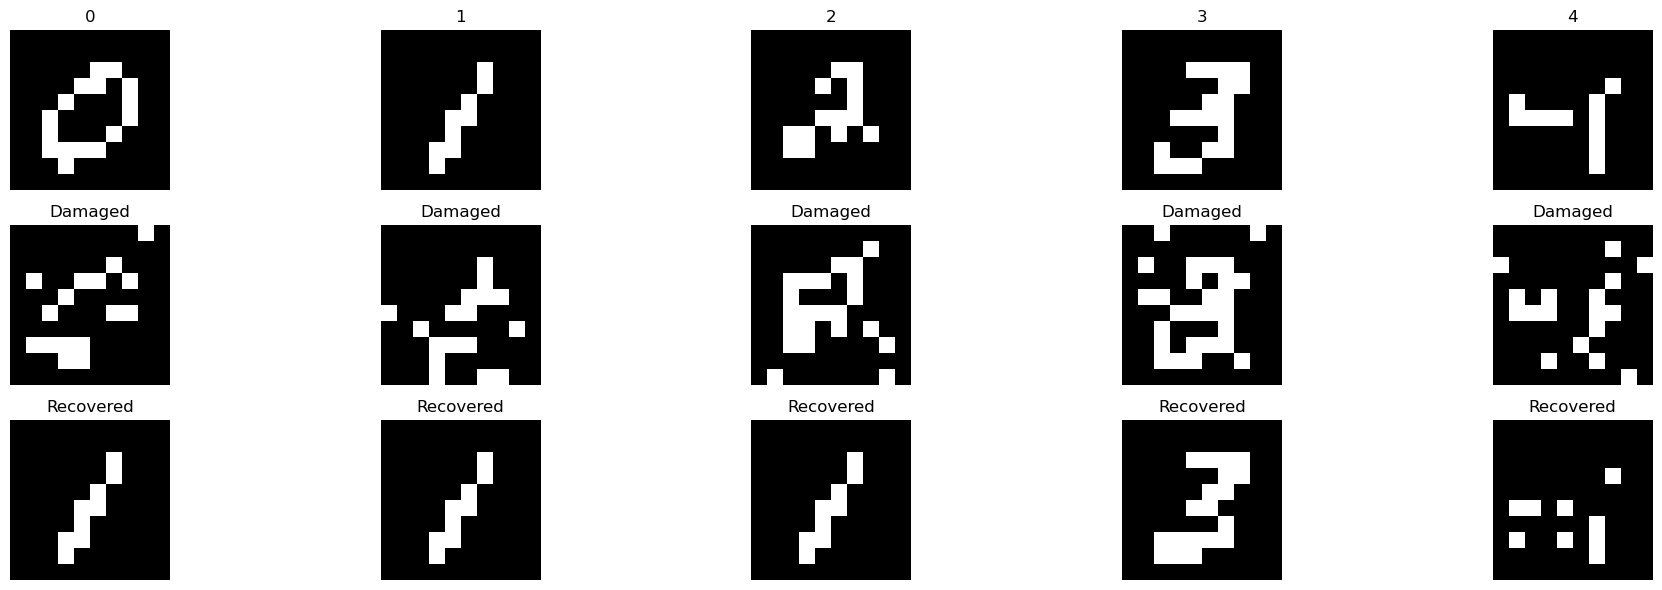

In [225]:

# -----------------------------
# 可调参数：网络总神经元数量（必须为完全平方数，如100、400、784等）
net_size = 100  # 例如 100 表示 10×10
num_imgs = 5
side = int(np.sqrt(net_size))  # 图像边长

# -----------------------------
# 1. 加载 MNIST 数据，选取数字 0～9 各一张图
(train_images, train_labels), _ = mnist.load_data()

selected_patterns = []
for digit in range(num_imgs):
    idx = np.where(train_labels == digit)[0][0]
    img = train_images[idx]
    selected_patterns.append(img)


# 1.new

# import numpy as np
# import matplotlib.pyplot as plt
# import scipy.io
#
# def load_mat_file(filename):
#     """
#     读入 .mat 文件，返回其中第一个非系统变量对应的矩阵
#     """
#     mat_data = scipy.io.loadmat(filename)
#     # 筛选掉 '__header__', '__version__', '__globals__' 等系统变量
#     keys = [key for key in mat_data.keys() if not key.startswith('__')]
#     # 假设第一个非系统变量就是我们需要的矩阵
#     return mat_data[keys[0]]
#
# def binarize_matrix(matrix, threshold=0):
#     """
#     将矩阵二值化：大于 threshold 的取 1，否则取 -1
#     """
#     return np.where(matrix > threshold, 1, -1)
#
# # 文件夹路径及状态列表
# folder = 'hnndata'
# selected_patterns = []
#
# # 依次加载 1.mat 到 10.mat
# for i in range(1, 11):
#     filename = f"{folder}/{i}.mat"
#     mat_matrix = load_mat_file(filename)  # 读入矩阵
#     print(mat_matrix)
#     # 二值化（根据实际情况可以调整 threshold，这里 threshold 设为 0）
#     bin_matrix = binarize_matrix(mat_matrix, threshold=0.1)
#     print(bin_matrix)
#     selected_patterns.append(bin_matrix)

# -----------------------------
# 2. 定义预处理函数：缩放 + 二值化
def preprocess_image(img, side, threshold=128):
    """
    缩放原始图像到 side x side，并二值化（像素值 > threshold 记为 +1，其它记为 -1）
    """
    # 缩放图像到 side x side（返回浮点型，值在0-1之间）
    img_resized = resize(img, (side, side), anti_aliasing=True)
    # 还原到0-255范围
    img_resized = img_resized * 255
    # 二值化
    bin_img = np.where(img_resized > threshold, 1, -1)
    return bin_img


# 对选取的图像进行预处理
processed_patterns = [preprocess_image(p, side) for p in selected_patterns]

# processed_patterns = selected_patterns



import numpy as np

# 假设 W 是你的 numpy 数组
# W = np.array([...])  # 用你的数据替换此处

# 1. 找到 W 中的最小值和最大值
# W_min = W.min()
# W_max = W.max()
#
# # 2. 将 W 归一化到 [0, 1] 范围内
# W_normalized = (W - W_min) / (W_max - W_min)
#
# # 3. 将归一化后的结果扩展到 [0, 15]，并四舍五入到最接近的整数
# W_quantized = np.round(W_normalized * 15)
#
# # 4. 可选：转换数据类型为无符号8位整数
# W_quantized = W_quantized.astype(np.uint8)
#
# print(W_quantized)
# W_dequantized = W_quantized / 15 * (W_max - W_min) + W_min
#
#
# W = W_dequantized

# -----------------------------
# 4. 定义异步更新函数（回忆过程）
def hopfield_recall(state, W, steps=10000):
    """
    state: 初始状态（side x side，取值 +1/-1）
    W: 训练好的权重矩阵
    steps: 更新次数上限
    返回: 收敛后的状态（side x side）
    """
    state_flat = state.flatten()
    N = state_flat.size
    for _ in range(steps):
        i = np.random.randint(0, N)  # 随机选择一个神经元
        h_i = np.dot(W[i, :], state_flat)
        state_flat[i] = 1 if h_i >= 0 else -1
    return state_flat.reshape((side, side))


def hopfield_recall_sync(state, W, steps=10000):
    """
    state: 初始状态（side x side，取值 +1 或 -1）
    W: 训练好的权重矩阵
    steps: 最大更新次数
    返回: 收敛后的状态（side x side）

    采用同步更新：每一步计算所有神经元的新状态，然后同时更新
    """
    state_flat = state.flatten()
    print(state_flat.shape)
    for _ in range(steps):
        # 同步计算所有神经元的净输入并更新状态
        # new_state = np.where(forward(state_flat) >= 0, 1, -1)
        new_state = np.where(np.dot(W, state_flat) >= 0, 1, -1)
        # 如果新状态与旧状态相同，则认为已收敛，退出循环
        if np.array_equal(new_state, state_flat):
            break
        state_flat = new_state
    return state_flat.reshape((state.shape))


import numpy as np

# -----------------------------
# 5. 定义损坏函数（随机翻转像素）
def damage_pattern(pattern, damage_rate=0.3):
    """
    随机翻转一定比例 (damage_rate) 的像素
    """
    damaged = pattern.copy().flatten()
    N = damaged.size
    num_flip = int(damage_rate * N)
    flip_indices = np.random.choice(N, num_flip, replace=False)
    damaged[flip_indices] *= -1
    return damaged.reshape((side, side))


# -----------------------------
# 6. 对每个数字测试：破坏后用 Hopfield 网络回忆
recovered_patterns = []
damaged_patterns = []
damage_rate = 0.1 # 例如翻转 30% 像素

for p in processed_patterns:
    damaged = damage_pattern(p, damage_rate)
    recovered = hopfield_recall_sync(damaged, W, steps=10)
    damaged_patterns.append(damaged)
    recovered_patterns.append(recovered)

# -----------------------------
# 7. 可视化展示原始、损坏与回忆后的图像
fig, axes = plt.subplots(num_imgs, 3, figsize=(8, 25))
for i in range(num_imgs):
    axes[i, 0].imshow(processed_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[i, 0].set_title(f"origin {i}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(damaged_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[i, 1].set_title("10% damage")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(recovered_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[i, 2].set_title("result")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, num_imgs, figsize=(20, 6))
for i in range(num_imgs):
    # 第一行：原始图像
    axes[0, i].imshow(processed_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].set_title(f"{i}")
    axes[0, i].axis('off')

    # 第二行：损坏图像
    axes[1, i].imshow(damaged_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].set_title("Damaged")
    axes[1, i].axis('off')

    # 第三行：回忆结果
    axes[2, i].imshow(recovered_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].set_title("Recovered")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()
